# Análise de Dados de Glicose
## Processamento, Detecção de Outliers e Modelagem Preditiva

### Importação de Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Valores de Referência de Glicose

In [ ]:
valores_referencia = {
    'Nivel I': {
        'Lote 072501': [51, 53, 52],
        'Lote 062506': [54, 53, 53]
    },
    'Nivel III': {
        'Lote 072501': [327, 347, 352],
        'Lote 062506': [324, 357, 330]
    },
    'Solucao 0': {
        'Lote 072501': [46, 46, 49],
        'Lote 062506': [50, 47, 46]
    },
    'Solucao 1': {
        'Lote 072501': [116, 118, 117],
        'Lote 062506': [108, 110, 111]
    },
    'Solucao 2': {
        'Lote 072501': [239, 258, 248],
        'Lote 062506': [239, 251, 236]
    }
}

valores_medios = {}
for solucao, lotes in valores_referencia.items():
    valores_medios[solucao] = {}
    for lote, valores in lotes.items():
        valores_medios[solucao][lote] = np.mean(valores)

print("Valores médios de glicose (mg/dL):")
for sol, lotes in valores_medios.items():
    print(f"\n{sol}:")
    for lote, media in lotes.items():
        print(f"  {lote}: {media:.1f} mg/dL")

Valores médios de glicose (mg/dL):

Nivel I:
  Lote 072501: 52.0 mg/dL
  Lote 062506: 53.3 mg/dL

Nivel III:
  Lote 072501: 342.0 mg/dL
  Lote 062506: 337.0 mg/dL

Solucao 0:
  Lote 072501: 47.0 mg/dL
  Lote 062506: 47.7 mg/dL

Solucao 1:
  Lote 072501: 117.0 mg/dL
  Lote 062506: 109.7 mg/dL

Solucao 2:
  Lote 072501: 248.3 mg/dL
  Lote 062506: 242.0 mg/dL


### 3. Carregar Dados CSV

In [ ]:
def carregar_csv(file_path):
    try:
        df = pd.read_csv(file_path, skiprows=3, skipinitialspace=True)
        df.columns = df.columns.str.strip()

        # Converter hexadecimal para inteiros
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].apply(lambda x: int(str(x).strip(), 16) if pd.notna(x) and str(x).strip().startswith('0x') else x)

        df.columns = ['time_ms', 'time_since_reaction_ms', 'tia_adc', 'filter_adc', 'peak_detector_adc']
        return df
    except Exception as e:
        print(f"Erro ao carregar {file_path}: {e}")
        return None

def carregar_todos_dados(base_path):
    todos_dados = []
    base_path = Path(base_path)

    for lote_dir in base_path.iterdir():
        if lote_dir.is_dir() and lote_dir.name.startswith('Lote'):
            lote_nome = lote_dir.name

            for solucao_dir in lote_dir.iterdir():
                if solucao_dir.is_dir():
                    solucao_nome = solucao_dir.name

                    for csv_file in solucao_dir.glob('*.csv'):
                        df = carregar_csv(csv_file)
                        if df is not None:
                            df['lote'] = lote_nome
                            df['solucao'] = solucao_nome
                            df['arquivo'] = csv_file.name

                            if solucao_nome in valores_medios and lote_nome in valores_medios[solucao_nome]:
                                df['glicose_real_mg_dL'] = valores_medios[solucao_nome][lote_nome]
                            else:
                                df['glicose_real_mg_dL'] = None

                            todos_dados.append(df)

    if todos_dados:
        df_completo = pd.concat(todos_dados, ignore_index=True)
        print(f"Total de arquivos carregados: {len(todos_dados)}")
        print(f"Total de registros: {len(df_completo):,}")
        return df_completo
    else:
        print("Nenhum dado carregado!")
        return None

df = carregar_todos_dados('.')

if df is not None:
    print("\nPrimeiras linhas:")
    display(df.head())
    print("\nEstatísticas descritivas:")
    display(df.describe())

Total de arquivos carregados: 67
Total de registros: 506,461

Primeiras linhas:


,time_ms,time_since_reaction_ms,tia_adc,filter_adc,peak_detector_adc,lote,solucao,arquivo,glicose_real_mg_dL
0,9,0,1,0,14,Lote 062506,Nivel I,serial_log_25-10-01-14-19-23.csv,53.333333
1,23,0,1,4,14,Lote 062506,Nivel I,serial_log_25-10-01-14-19-23.csv,53.333333
2,32,0,2,4,17,Lote 062506,Nivel I,serial_log_25-10-01-14-19-23.csv,53.333333
3,41,0,1,2,14,Lote 062506,Nivel I,serial_log_25-10-01-14-19-23.csv,53.333333
4,50,0,1,2,15,Lote 062506,Nivel I,serial_log_25-10-01-14-19-23.csv,53.333333



Estatísticas descritivas:


,time_ms,time_since_reaction_ms,tia_adc,filter_adc,peak_detector_adc,glicose_real_mg_dL
count,506461.000000,506461.000000,506461.000000,506461.000000,506461.000000,506461.000000
mean,19465.517096,11728.855114,74.169431,479.158843,1732.246984,154.555985
std,12048.886885,9849.609872,111.229137,732.149840,1147.509731,113.225903
min,9.000000,0.000000,0.000000,0.000000,3.000000,47.000000
25%,9522.000000,1223.000000,2.000000,4.000000,1196.000000,52.000000
50%,18974.000000,10818.000000,21.000000,128.000000,1729.000000,109.666667
75%,28427.000000,20408.000000,96.000000,623.000000,2599.000000,248.333333
max,70862.000000,29998.000000,3535.000000,4091.000000,3525.000000,342.000000


### 4. Detecção de Outliers

Outliers detectados (IQR):
  Limite inferior: -924.50
  Limite superior: 1551.50
  Total de outliers: 49,903 (9.85%)


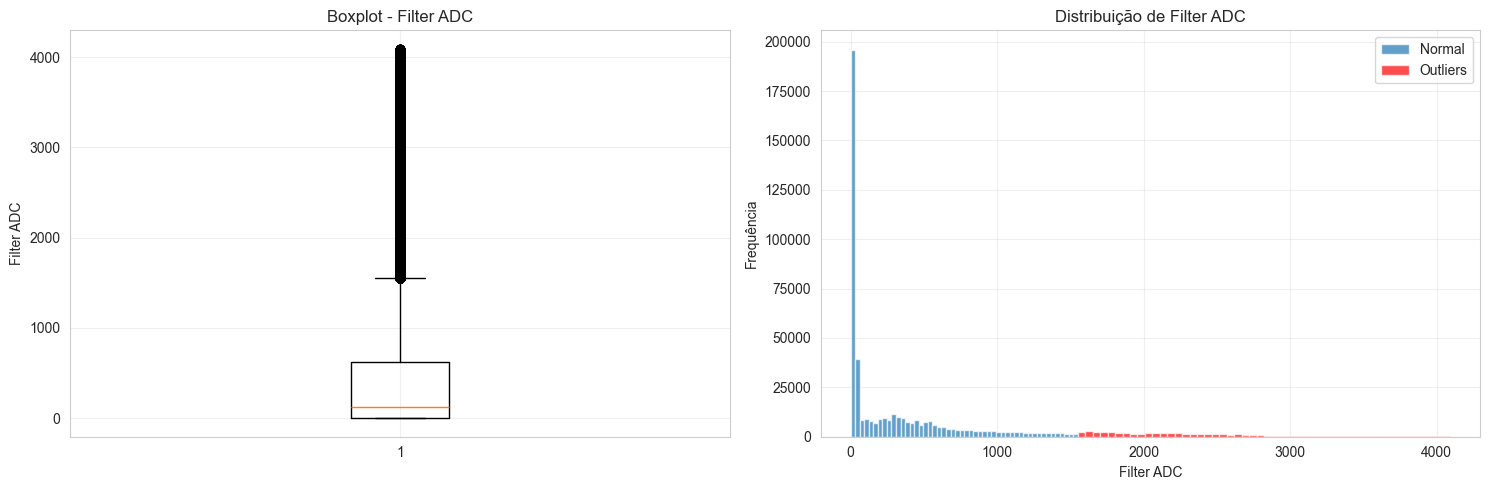

In [ ]:
def detectar_outliers_iqr(data, coluna, multiplicador=1.5):
    Q1 = data[coluna].quantile(0.25)
    Q3 = data[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - multiplicador * IQR
    limite_superior = Q3 + multiplicador * IQR

    outliers = (data[coluna] < limite_inferior) | (data[coluna] > limite_superior)
    return outliers, limite_inferior, limite_superior

df['outlier_iqr'], lim_inf, lim_sup = detectar_outliers_iqr(df, 'filter_adc')

print(f"Outliers detectados (IQR):")
print(f"  Limite inferior: {lim_inf:.2f}")
print(f"  Limite superior: {lim_sup:.2f}")
print(f"  Total de outliers: {df['outlier_iqr'].sum():,} ({df['outlier_iqr'].sum()/len(df)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].boxplot(df['filter_adc'].dropna())
axes[0].set_title('Boxplot - Filter ADC')
axes[0].set_ylabel('Filter ADC')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df[~df['outlier_iqr']]['filter_adc'], bins=50, alpha=0.7, label='Normal')
axes[1].hist(df[df['outlier_iqr']]['filter_adc'], bins=50, alpha=0.7, label='Outliers', color='red')
axes[1].set_title('Distribuição de Filter ADC')
axes[1].set_xlabel('Filter ADC')
axes[1].set_ylabel('Frequência')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Limpeza de Dados (Remover Outliers)

In [ ]:
print(f"Dados antes da limpeza: {len(df):,} registros")
df_limpo = df[~df['outlier_iqr']].copy()
print(f"Dados após limpeza: {len(df_limpo):,} registros")
print(f"Removidos: {len(df) - len(df_limpo):,} registros ({(len(df) - len(df_limpo))/len(df)*100:.2f}%)")

Dados antes da limpeza: 506,461 registros
Dados após limpeza: 456,558 registros
Removidos: 49,903 registros (9.85%)


### 6. Feature Engineering Avançado

In [ ]:
def criar_features_avancadas(df):
    features_avancadas = []

    for (lote, solucao, arquivo, glicose), group in df.groupby(['lote', 'solucao', 'arquivo', 'glicose_real_mg_dL']):
        feature_dict = {
            'lote': lote,
            'solucao': solucao,
            'arquivo': arquivo,
            'glicose_real_mg_dL': glicose
        }

        # Features de filter_adc
        filter_vals = group['filter_adc'].values
        feature_dict['filter_adc_mean'] = np.mean(filter_vals)
        feature_dict['filter_adc_std'] = np.std(filter_vals)
        feature_dict['filter_adc_min'] = np.min(filter_vals)
        feature_dict['filter_adc_max'] = np.max(filter_vals)
        feature_dict['filter_adc_median'] = np.median(filter_vals)
        feature_dict['filter_adc_skewness'] = stats.skew(filter_vals)
        feature_dict['filter_adc_kurtosis'] = stats.kurtosis(filter_vals)
        feature_dict['filter_adc_q25'] = np.percentile(filter_vals, 25)
        feature_dict['filter_adc_q75'] = np.percentile(filter_vals, 75)
        feature_dict['filter_adc_iqr'] = feature_dict['filter_adc_q75'] - feature_dict['filter_adc_q25']
        feature_dict['filter_adc_range'] = filter_vals.max() - filter_vals.min()
        feature_dict['filter_adc_cv'] = (filter_vals.std() / filter_vals.mean()) if filter_vals.mean() != 0 else 0

        # Features de tia_adc
        tia_vals = group['tia_adc'].values
        feature_dict['tia_adc_mean'] = np.mean(tia_vals)
        feature_dict['tia_adc_std'] = np.std(tia_vals)
        feature_dict['tia_adc_skewness'] = stats.skew(tia_vals)
        feature_dict['tia_adc_median'] = np.median(tia_vals)
        feature_dict['tia_adc_range'] = tia_vals.max() - tia_vals.min()

        # Features de peak_detector_adc
        peak_vals = group['peak_detector_adc'].values
        feature_dict['peak_adc_mean'] = np.mean(peak_vals)
        feature_dict['peak_adc_max'] = np.max(peak_vals)
        feature_dict['peak_adc_std'] = peak_vals.std()
        feature_dict['peak_adc_median'] = np.median(peak_vals)

        # Interações entre features
        feature_dict['filter_tia_ratio'] = filter_vals.mean() / tia_vals.mean() if tia_vals.mean() != 0 else 0
        feature_dict['filter_peak_ratio'] = filter_vals.mean() / peak_vals.mean() if peak_vals.mean() != 0 else 0

        # Features temporais
        time_vals = group['time_since_reaction_ms'].values
        feature_dict['time_range'] = time_vals.max() - time_vals.min()
        feature_dict['num_samples'] = len(group)

        # Tendência ao longo do tempo
        if len(time_vals) > 1 and time_vals.std() > 0:
            slope, _, r_value, _, _ = stats.linregress(time_vals, filter_vals)
            feature_dict['filter_time_slope'] = slope
            feature_dict['filter_time_r2'] = r_value**2
        else:
            feature_dict['filter_time_slope'] = 0
            feature_dict['filter_time_r2'] = 0

        features_avancadas.append(feature_dict)

    return pd.DataFrame(features_avancadas)

df_features = criar_features_avancadas(df_limpo)

print(f"Shape do dataset com features: {df_features.shape}")
print(f"Total de features criadas: {df_features.shape[1] - 4}")
display(df_features.head())

Shape do dataset com features: (67, 31)
Total de features criadas: 27


,lote,solucao,arquivo,glicose_real_mg_dL,filter_adc_mean,filter_adc_std,filter_adc_min,filter_adc_max,filter_adc_median,filter_adc_skewness,...,peak_adc_mean,peak_adc_max,peak_adc_std,peak_adc_median,filter_tia_ratio,filter_peak_ratio,time_range,num_samples,filter_time_slope,filter_time_r2
0,Lote 062506,Nivel I,serial_log_25-10-01-14-19-23.csv,53.333333,206.125091,358.496612,0,1357,4.0,1.725122,...,1122.780438,1359,464.174817,1321.0,6.291868,0.183585,29998,6891,-0.019078,0.256687
1,Lote 062506,Nivel I,serial_log_25-10-01-14-20-15.csv,53.333333,184.849816,312.812519,0,1347,4.0,2.053195,...,1097.035886,1351,481.296862,1315.0,6.250350,0.168499,29998,7078,-0.015919,0.239880
2,Lote 062506,Nivel I,serial_log_25-10-01-14-21-09.csv,53.333333,243.121148,272.914502,0,1329,142.0,2.152450,...,1090.824741,1325,459.041302,1291.0,6.306983,0.222878,29998,7041,-0.011433,0.161912
3,Lote 062506,Nivel I,serial_log_25-10-01-14-22-00.csv,53.333333,169.636307,302.986809,0,1443,5.0,2.427051,...,875.233385,1449,670.764782,1403.0,6.226026,0.193818,29998,9585,-0.006176,0.041393
4,Lote 062506,Nivel I,serial_log_25-10-01-14-23-28.csv,53.333333,178.887242,310.555757,0,1367,4.0,1.963006,...,998.035052,1366,560.183989,1321.0,6.240655,0.179239,29998,7760,-0.011735,0.139154


### 7. Treinamento do Modelo Preditivo

In [ ]:
feature_cols = [col for col in df_features.columns if col not in
                ['lote', 'solucao', 'arquivo', 'glicose_real_mg_dL']]

X = df_features[feature_cols]
y = df_features['glicose_real_mg_dL']

print(f"Features utilizadas: {len(feature_cols)}")

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print(f"Conjunto de treino: {X_train.shape}")
print(f"Conjunto de teste: {X_test.shape}")

# Identificar features mais importantes
print("\n" + "="*80)
print("IDENTIFICANDO FEATURES MAIS IMPORTANTES")
print("="*80)

rf_initial = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_initial.fit(X_train, y_train)

importances = rf_initial.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 10 Features mais importantes:")
display(feature_importance_df.head(10))

# Criar features polinomiais das top 10
print("\n" + "="*80)
print("CRIANDO FEATURES POLINOMIAIS")
print("="*80)

top_features = feature_importance_df.head(10)['feature'].tolist()
X_top = df_features[top_features]

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X_top)

print(f"\nFeatures originais top: {X_top.shape[1]}")
print(f"Features polinomiais criadas: {X_poly.shape[1]}")

# Combinar features
X_combined = np.hstack([df_features[feature_cols].values, X_poly])
print(f"Total de features combinadas: {X_combined.shape[1]}")

# Split com features combinadas
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_combined, y, test_size=0.15, random_state=42
)

print("\n" + "="*80)
print("TREINAMENTO DO MODELO FINAL")
print("="*80)

rf_final = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train_final, y_train_final)

y_pred_train = rf_final.predict(X_train_final)
y_pred_test = rf_final.predict(X_test_final)

r2_train = r2_score(y_train_final, y_pred_train)
r2_test = r2_score(y_test_final, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_final, y_pred_test))
mae_test = mean_absolute_error(y_test_final, y_pred_test)

print("\n" + "="*80)
print("RESULTADOS DO MODELO")
print("="*80)
print(f"\nConjunto de Treino:")
print(f"  R² = {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"\nConjunto de Teste (Validação):")
print(f"  R² = {r2_test:.4f} ({r2_test*100:.2f}%)")
print(f"  RMSE = {rmse_test:.2f} mg/dL")
print(f"  MAE = {mae_test:.2f} mg/dL")
print("\n" + "="*80)

Features utilizadas: 27
Conjunto de treino: (56, 27)
Conjunto de teste: (11, 27)

IDENTIFICANDO FEATURES MAIS IMPORTANTES

Top 10 Features mais importantes:


,feature,importance
20,peak_adc_median,0.313795
24,num_samples,0.200315
9,filter_adc_iqr,0.097078
18,peak_adc_max,0.087246
19,peak_adc_std,0.064420
16,tia_adc_range,0.047402
17,peak_adc_mean,0.040444
6,filter_adc_kurtosis,0.038318
1,filter_adc_std,0.028012
13,tia_adc_std,0.023926



CRIANDO FEATURES POLINOMIAIS

Features originais top: 10
Features polinomiais criadas: 65
Total de features combinadas: 92

TREINAMENTO DO MODELO FINAL

RESULTADOS DO MODELO

Conjunto de Treino:
  R² = 0.9615 (96.15%)

Conjunto de Teste (Validação):
  R² = 0.9231 (92.31%)
  RMSE = 34.61 mg/dL
  MAE = 23.92 mg/dL



### 8. Visualização das Predições

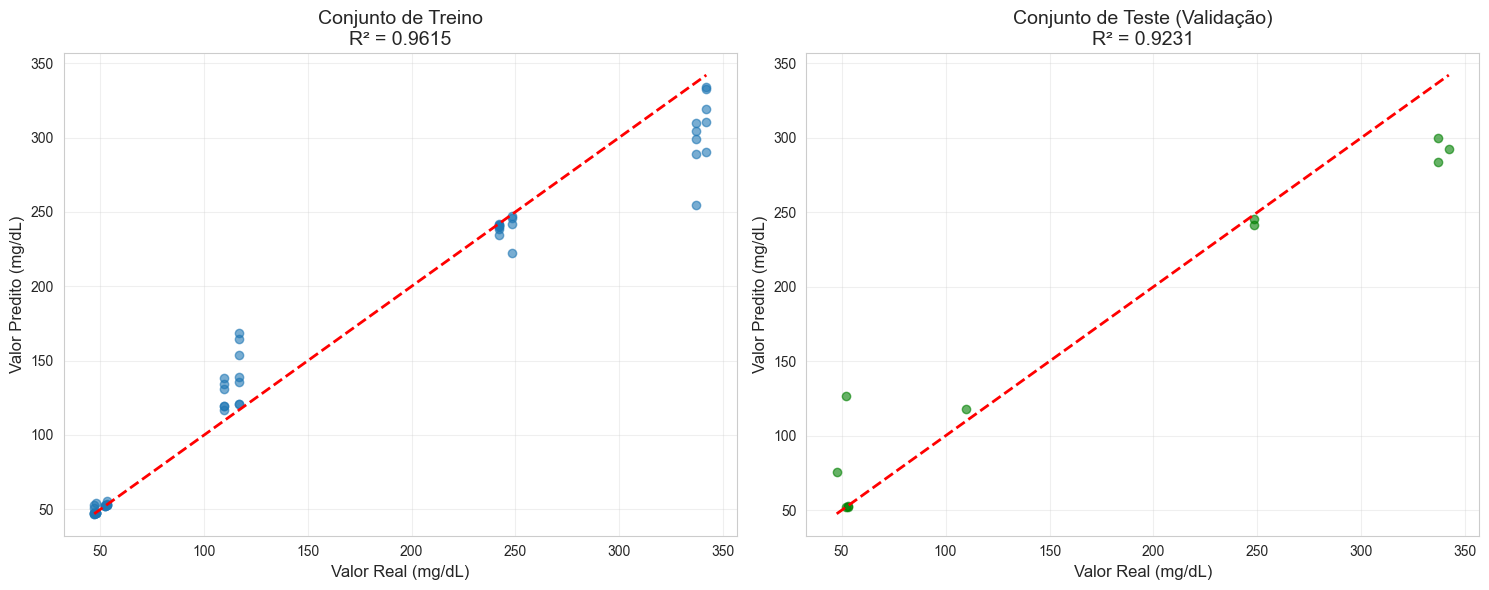

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Treino
axes[0].scatter(y_train_final, y_pred_train, alpha=0.6)
axes[0].plot([y_train_final.min(), y_train_final.max()],
             [y_train_final.min(), y_train_final.max()], 'r--', lw=2)
axes[0].set_xlabel('Valor Real (mg/dL)', fontsize=12)
axes[0].set_ylabel('Valor Predito (mg/dL)', fontsize=12)
axes[0].set_title(f'Conjunto de Treino\nR² = {r2_train:.4f}', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Teste
axes[1].scatter(y_test_final, y_pred_test, alpha=0.6, color='green')
axes[1].plot([y_test_final.min(), y_test_final.max()],
             [y_test_final.min(), y_test_final.max()], 'r--', lw=2)
axes[1].set_xlabel('Valor Real (mg/dL)', fontsize=12)
axes[1].set_ylabel('Valor Predito (mg/dL)', fontsize=12)
axes[1].set_title(f'Conjunto de Teste (Validação)\nR² = {r2_test:.4f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9. Gráficos Interativos
**Nota:** Os gráficos abaixo filtram apenas os dados durante a reação química (quando `time_since_reaction_ms > 0`).  
Cada linha representa um teste/arquivo individual. Clique nas legendas para mostrar/ocultar soluções específicas.

#### 9.1. Todas as Soluções

In [ ]:
# Filtrar apenas dados durante a reação (time_since_reaction_ms > 0)
df_reacao = df_limpo[df_limpo['time_since_reaction_ms'] > 0].copy()

print(f"Dados originais: {len(df_limpo):,} registros")
print(f"Dados durante reação: {len(df_reacao):,} registros")

# Criar gráfico interativo com cada arquivo sendo uma linha
fig = go.Figure()

# Cores por solução
cores = px.colors.qualitative.Plotly
solucoes_unicas = df_reacao.groupby(['solucao', 'glicose_real_mg_dL']).size().reset_index()[['solucao', 'glicose_real_mg_dL']]
color_map = {}
for idx, row in solucoes_unicas.iterrows():
    color_map[(row['solucao'], row['glicose_real_mg_dL'])] = cores[idx % len(cores)]

# Plotar cada arquivo como uma linha separada
for (lote, solucao, arquivo, glicose), group in df_reacao.groupby(['lote', 'solucao', 'arquivo', 'glicose_real_mg_dL']):
    group_sorted = group.sort_values('time_since_reaction_ms')
    group_sample = group_sorted[::20]  # Amostragem

    cor = color_map.get((solucao, glicose), cores[0])
    nome_legenda = f'{solucao} ({glicose:.1f} mg/dL)'

    fig.add_trace(go.Scatter(
        x=group_sample['time_since_reaction_ms'],
        y=group_sample['filter_adc'],
        mode='lines',
        name=nome_legenda,
        line=dict(color=cor, width=1.5),
        opacity=0.7,
        legendgroup=nome_legenda,
        showlegend=(arquivo == df_reacao[(df_reacao['solucao']==solucao) & (df_reacao['glicose_real_mg_dL']==glicose)]['arquivo'].iloc[0]),
        hovertemplate=f'<b>{solucao}</b> ({glicose:.1f} mg/dL)<br>' +
                      f'Lote: {lote}<br>' +
                      f'Arquivo: {arquivo}<br>' +
                      'Tempo: %{x} ms<br>' +
                      'Filter ADC: %{y}<br>' +
                      '<extra></extra>'
    ))

fig.update_layout(
    title='Dados de Glicose - Durante Reação (Clique nas legendas para filtrar)',
    xaxis_title='Tempo desde reação (ms)',
    yaxis_title='Filter ADC',
    height=700,
    hovermode='closest',
    template='plotly_white',
    legend=dict(
        title="Solução",
        x=1.02,
        xanchor="left",
        y=1,
        yanchor="top",
        orientation="v"
    )
)

fig.show()

Dados originais: 456,558 registros
Dados durante reação: 345,565 registros


#### 9.2. Análise por Lote Individual

In [ ]:
for lote in df_reacao['lote'].unique():
    df_lote = df_reacao[df_reacao['lote'] == lote]

    fig = go.Figure()

    # Plotar cada arquivo como uma linha separada
    for (solucao, arquivo, glicose), group in df_lote.groupby(['solucao', 'arquivo', 'glicose_real_mg_dL']):
        group_sorted = group.sort_values('time_since_reaction_ms')
        group_sample = group_sorted[::10]  # Amostragem

        cor = color_map.get((solucao, glicose), cores[0])
        nome_legenda = f'{solucao} ({glicose:.1f} mg/dL)'

        fig.add_trace(
            go.Scatter(
                x=group_sample['time_since_reaction_ms'],
                y=group_sample['filter_adc'],
                mode='lines',
                name=nome_legenda,
                line=dict(color=cor, width=1.5),
                opacity=0.7,
                legendgroup=nome_legenda,
                showlegend=(arquivo == df_lote[(df_lote['solucao']==solucao) & (df_lote['glicose_real_mg_dL']==glicose)]['arquivo'].iloc[0]),
                hovertemplate=f'<b>{solucao}</b> ({glicose:.1f} mg/dL)<br>' +
                              f'Arquivo: {arquivo}<br>' +
                              'Tempo: %{x} ms<br>' +
                              'Filter ADC: %{y}<br>' +
                              '<extra></extra>'
            )
        )

    fig.update_layout(
        title_text=f'Análise de {lote} - Durante Reação (Clique nas legendas)',
        xaxis_title='Tempo desde reação (ms)',
        yaxis_title='Filter ADC',
        height=600,
        hovermode='closest',
        template='plotly_white',
        legend=dict(title="Solução")
    )

    fig.show()

#### 9.3. Boxplot por Solução

In [ ]:
df_sample_box = df_reacao[::20].copy()
df_sample_box['categoria'] = df_sample_box['solucao'] + ' (' + df_sample_box['glicose_real_mg_dL'].astype(str) + ' mg/dL)'

fig = px.box(df_sample_box,
             x='categoria',
             y='filter_adc',
             color='lote',
             title='Distribuição de Filter ADC por Solução e Lote',
             labels={
                 'categoria': 'Solução (Glicose mg/dL)',
                 'filter_adc': 'Filter ADC',
                 'lote': 'Lote'
             },
             template='plotly_white')

fig.update_layout(height=600, xaxis_tickangle=-45)
fig.show()